# Lectutorial 4: Sequential data, RNNs and Transformer

Some of the content in this notebook are reused or adapted from [Aurelien Geron repository](https://github.com/ageron). 

In [250]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch import nn
import sys


In [2]:
# To install libraries needed for this part on Colab
if "google.colab" in sys.modules:
  %pip install torchmetrics
import torchmetrics

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

## Coding time 1: Using RNNs

In this part, we will have a look at some time series data, and see how we can use an RNN to make predictions for future time steps.

### 1.1. Time series forecasting: Daily Train and Bus Ridership in Chicago

First, let's load the dataset. We will use the Chicago Transit Authority (CTA) Daily Boarding dataset. It contains the number of people boarding train and buses in Chicago daily. You can use the file uploaded on Canvas, or directly download the dataset from the [Chicago Data Portal](https://data.cityofchicago.org/Transportation/CTA-Ridership-Daily-Boarding-Totals/6iiy-9s97/about_data).

In [5]:
# Mount your Google Drive on Colab if your are loading the dataset file from your Drive
# Else you can ignore this cell
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the dataset as a Pandas DataFrame + quick pre-processing
path = Path("drive/MyDrive/ColabNotebooks/Datasets/CTA_-_Ridership_-_Daily_Boarding_Totals.csv") # Replace with your path to the dataset file
df_ridership = pd.read_csv(path, parse_dates=["service_date"])
df_ridership.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df_ridership = df_ridership.sort_values("date").set_index("date")
df_ridership = df_ridership.drop("total", axis=1) # no need for total, it's just bus + rail
df_ridership = df_ridership.drop_duplicates() # remove duplicated months

Visualise the 5 first instances of the dataset.

In [118]:
df_ridership.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's have a quick look at what the data looks like over a couple of months:

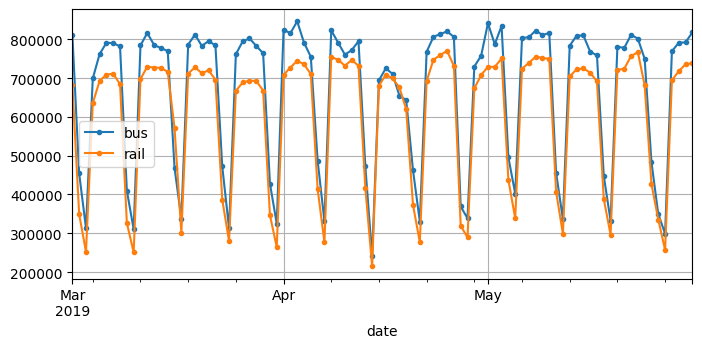

In [7]:
df_ridership["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

**TODO**: Change the dates in the plot to visualise the figures at other periods. E.g., visualise the data between March 2020 and May 2020. What do you notice? Can you link this to any event you are aware of?

This is a *time series*, i.e., data with different values at different time steps, with regular intervals. More precisely, this is a *multivariate time series* as we have two values for each time steps (bus and rail riderships). If we were focusing on only one value, this would be a *univariate time series*. We will train models to do prediction of future values based on historical values, i.e., forecasting. However, you can perform other tasks on time series, such as for example classification, imputation and anomaly detection.


**TODO**: Do you notice anything interesting with the data?

Based on this observation, we could try to use *naive forecasting*, i.e., predict future values as being past values lagged by a specific number fo timesteps. What *lag* value should we use here?

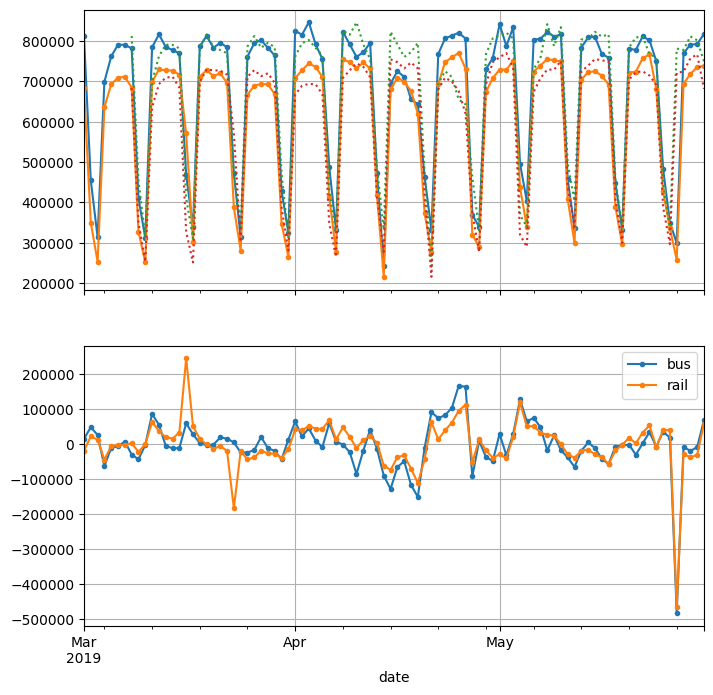

In [9]:
# Plot the original time series
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
df_ridership["2019-03":"2019-05"].plot(ax=axs[0], legend=False, marker=".") # original time series
#Define a lag value and plot the lagged time series
lag_value = 7
df_ridership["2019-03":"2019-05"].shift(lag_value).plot(ax=axs[0], grid=True, legend=False, linestyle=":") # lagged

# Calculate and plot the difference between the original and lagged time series
lagged_df_ridership = df_ridership[["bus", "rail"]].diff(lag_value)["2019-03":"2019-05"] # Store
lagged_df_ridership.plot(ax=axs[1], grid=True, marker=".") # difference between the time series
plt.show()

Let's calculate the MAE for this *naive forecasting* approach.

In [10]:
lagged_df_ridership.abs().mean()

,0
bus,43915.608696
rail,42143.271739


We can express the MAE in percentage by dividing the errors by the target values, i.e., calculating the MAPE (Mean Absolute Percentage Error).

In [11]:
targets = df_ridership[["bus", "rail"]]["2019-03":"2019-05"]
(lagged_df_ridership / targets).abs().mean()

,0
bus,0.082938
rail,0.089948


**TODO**: Why is the MAE for bus ridership higher than the MAE for rail ridership, while the MAPE for bus ridership is lower than the MAPE for rail ridership?

#### 1.1.1. Setting a baseline: Linear Model

Before trying to use a RNN, let's see if trianing a simple linear model can lead to better performance than the naive forecasting.

First, we need to prepare the data for the training. This task is different than what we are used to so far. There are no predefined (x,y) instances, so what should we use for training data and target?



We can use the following class to create a dataset by choping the time series into all possible windows of a given length, and the corresponding targets.

In [110]:
class TimeSeriesDataset(torch.utils.data.Dataset):
  def __init__(self, series, window_length):
    self.series = series
    self.window_length = window_length

  def __len__(self):
    return len(self.series) - self.window_length

  def __getitem__(self, idx):
    if idx >= len(self):
      raise IndexError("dataset index out of range")
    end = idx + self.window_length # 1st index after window
    window = self.series[idx : end]
    target = self.series[end]
    return window, target

Let's test it with a toy time series.

In [66]:
my_series = torch.tensor([[0], [1], [2], [3], [4], [5], [6], [7], [8]])
my_dataset = TimeSeriesDataset(my_series, window_length=3)
for window, target in my_dataset:
  print("Window:", window, " Target:", target)

Window: tensor([[0],
        [1],
        [2]])  Target: tensor([3])
Window: tensor([[1],
        [2],
        [3]])  Target: tensor([4])
Window: tensor([[2],
        [3],
        [4]])  Target: tensor([5])
Window: tensor([[3],
        [4],
        [5]])  Target: tensor([6])
Window: tensor([[4],
        [5],
        [6]])  Target: tensor([7])
Window: tensor([[5],
        [6],
        [7]])  Target: tensor([8])


Given the number of elements in the toy time series and the chosen window size, we get a dataset with 6 combinaisons of window/target,

**TODO**: Try changing the window size to see the effect on the dataset.

We can now create a DataLoader to create batches of windows:

In [67]:
my_loader = DataLoader(my_dataset, batch_size=2, shuffle=True)
for X, y in my_loader:
  print("X:", X, " y:", y)

X: tensor([[[1],
         [2],
         [3]],

        [[4],
         [5],
         [6]]])  y: tensor([[4],
        [7]])
X: tensor([[[5],
         [6],
         [7]],

        [[0],
         [1],
         [2]]])  y: tensor([[8],
        [3]])
X: tensor([[[2],
         [3],
         [4]],

        [[3],
         [4],
         [5]]])  y: tensor([[5],
        [6]])


Let's now apply it to our ridership timeseries. To start with, we only focus on the rail risership (univariate case).

We need first to convert the data to torch tensors, and we also decide to scale the values down by a factor 1e6, to get value close to 0 (better for training as we saw last week). We also split the data in training, validation and test sets, using different periods of time for each set.

If we had data for different cities, we could try to train on some cities, and validate/test on other ones.

In [7]:
rail_train = torch.FloatTensor(df_ridership[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df_ridership[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df_ridership[["rail"]]["2019-06":].values / 1e6)

Let's use a window size of 56 days (8 weeks) to create the

In [8]:
window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [111]:
def train(model, optimizer, loss_fn, eval_metric, train_loader, valid_loader, n_epochs):
    train_losses = []
    train_eval_metrics = []
    valid_losses = []
    valid_eval_metrics= []

    for epoch in range(n_epochs):

        #Training
        eval_metric.reset() # Reset the eval metric
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            eval_metric.update(y_train_pred, y_train_batch) # Update eval metric for training
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)
        # Calculte and store training eval metric for this epoch
        epoch_training_eval_metric = eval_metric.compute().item()
        train_eval_metrics.append(epoch_training_eval_metric)

        # Model evaluation
        model.eval()
        eval_metric.reset() # Reset the eval metric
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()  # Update eval metric for validation
                eval_metric.update(y_valid_pred, y_valid_batch)
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)
        # Calculte and store validation eval metric for this epoch
        epoch_valid_eval_metric = eval_metric.compute().item()
        valid_eval_metrics.append(epoch_valid_eval_metric)

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")
        print(f"Epoch {epoch + 1}/{n_epochs}, Training Eval Metric: {epoch_training_eval_metric:.4f}, Valid Eval Metric: {epoch_valid_eval_metric:.4f}")

    return (train_losses, valid_losses, train_eval_metrics, valid_eval_metrics)

Before trying to use a RNN, let's see how a simple linear model (one neuron with linear activation) performs.

Note that we need to flatten the data before the `Linear` layer because the input have a shape [*batch size, window length, dimensionality*] while the `Linear` layer excepts a shape [*batch size, features*].

In [56]:
torch.manual_seed(10)
linear_model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)
n_epochs = 40
train_losses, valid_losses, mae_train, mae_valid = train(linear_model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs)

Epoch 1/40, Training Loss: 0.0495, Valid Loss: 0.0170
Epoch 1/40, Training Eval Metric: 0.2515, Valid Eval Metric: 0.1267
Epoch 2/40, Training Loss: 0.0138, Valid Loss: 0.0089
Epoch 2/40, Training Eval Metric: 0.1292, Valid Eval Metric: 0.1114
Epoch 3/40, Training Loss: 0.0091, Valid Loss: 0.0062
Epoch 3/40, Training Eval Metric: 0.1033, Valid Eval Metric: 0.0862
Epoch 4/40, Training Loss: 0.0078, Valid Loss: 0.0051
Epoch 4/40, Training Eval Metric: 0.0889, Valid Eval Metric: 0.0764
Epoch 5/40, Training Loss: 0.0068, Valid Loss: 0.0045
Epoch 5/40, Training Eval Metric: 0.0825, Valid Eval Metric: 0.0706
Epoch 6/40, Training Loss: 0.0061, Valid Loss: 0.0041
Epoch 6/40, Training Eval Metric: 0.0761, Valid Eval Metric: 0.0671
Epoch 7/40, Training Loss: 0.0060, Valid Loss: 0.0038
Epoch 7/40, Training Eval Metric: 0.0736, Valid Eval Metric: 0.0632
Epoch 8/40, Training Loss: 0.0057, Valid Loss: 0.0037
Epoch 8/40, Training Eval Metric: 0.0718, Valid Eval Metric: 0.0626
Epoch 9/40, Training Los

If we want to get the MAE in the original metric (number of riders), we need to multiply it by the factor used in the scaling before training.

In [57]:
mae_train = [x * 1e6 for x in mae_train]
mae_valid = [x * 1e6 for x in mae_valid]

In [58]:
mae_valid[-1]

45297.34328389168

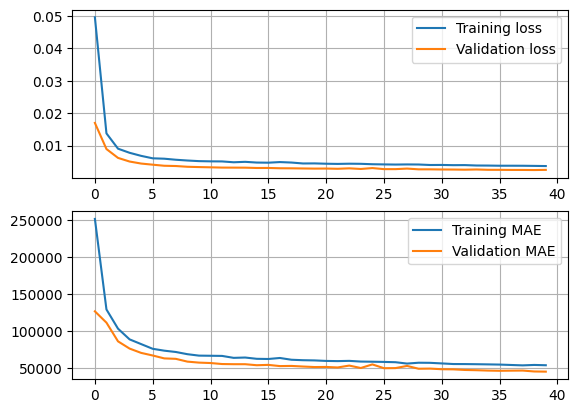

In [59]:
plt.subplot(2, 1, 1)
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(mae_train, label='Training MAE')
plt.plot(mae_valid, label='Validation MAE')
plt.grid()
plt.legend()

#### 1.1.2. Simple RNN for ridership time series forecasting

Let's now try to use a RNN to perform the same task.

PyTorch comes with a `nn.RNN` module that implements an RNN cell. This is a slightly different version from the one we described in class:


*   It only implements the activation calculation (we will need a seperate layer to calculate the output).
*   It uses 2 seperate biases, one applied the inputs and one to the previous activation. In the version seen in class, these 2 biases are combined into 1.

The following class implements a RNN with 1 RNN cell and 1 output layer.

In [14]:
class SimpleRnnModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.RNN(input_size, hidden_size, batch_first=True) # batch_first=True because the shape of our data is [batch size, window length, dimensionality]
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])


We now set:


*   the input size to 1 because we have a univariate time series (i.e, 1 value is fed at each time step),
*   the number of recurrent neurons to 20 (hyperparameter to be tuned),
*   the ouput size to 1 because we only predict the rail ridership value.



In [214]:
torch.manual_seed(10)
univar_model = SimpleRnnModel(input_size=1, hidden_size=20, output_size=1).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.Adam(univar_model.parameters(), lr=0.005)
metric = torchmetrics.MeanAbsoluteError().to(device)
n_epochs = 40
train_losses, valid_losses, mae_train, mae_valid = train(univar_model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs)

Epoch 1/40, Training Loss: 0.0362, Valid Loss: 0.0169
Epoch 1/40, Training Eval Metric: 0.2103, Valid Eval Metric: 0.1217
Epoch 2/40, Training Loss: 0.0145, Valid Loss: 0.0120
Epoch 2/40, Training Eval Metric: 0.1486, Valid Eval Metric: 0.1255
Epoch 3/40, Training Loss: 0.0100, Valid Loss: 0.0070
Epoch 3/40, Training Eval Metric: 0.1175, Valid Eval Metric: 0.1032
Epoch 4/40, Training Loss: 0.0084, Valid Loss: 0.0074
Epoch 4/40, Training Eval Metric: 0.1009, Valid Eval Metric: 0.1008
Epoch 5/40, Training Loss: 0.0081, Valid Loss: 0.0068
Epoch 5/40, Training Eval Metric: 0.0992, Valid Eval Metric: 0.0996
Epoch 6/40, Training Loss: 0.0076, Valid Loss: 0.0072
Epoch 6/40, Training Eval Metric: 0.0956, Valid Eval Metric: 0.0931
Epoch 7/40, Training Loss: 0.0075, Valid Loss: 0.0071
Epoch 7/40, Training Eval Metric: 0.0942, Valid Eval Metric: 0.0918
Epoch 8/40, Training Loss: 0.0057, Valid Loss: 0.0040
Epoch 8/40, Training Eval Metric: 0.0809, Valid Eval Metric: 0.0687
Epoch 9/40, Training Los

In [215]:
mae_train = [x * 1e6 for x in mae_train]
mae_valid = [x * 1e6 for x in mae_valid]

In [216]:
mae_valid[-1]

37911.657243967056

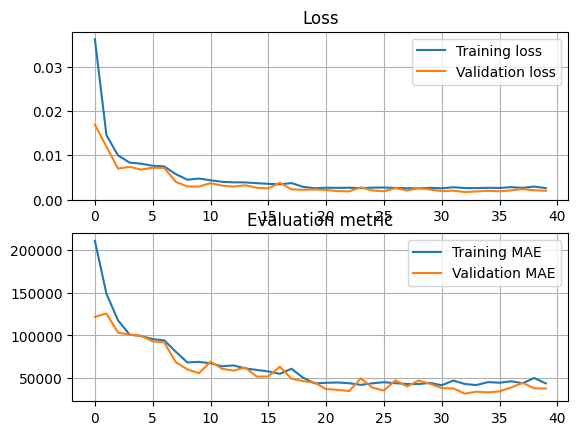

In [63]:
plt.subplot(2, 1, 1)
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.title("Loss")
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(mae_train, label='Training MAE')
plt.plot(mae_valid, label='Validation MAE')
plt.title("Evaluation metric")
plt.grid()
plt.legend()

#### 1.1.3. Multiple-layer RNN for ridership time series forecasting

We can also use several layers of RNN, just by specifying the `num_layers` parameter of the `nn.RNN` module.

In [70]:
class MLRnnModel(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size):
    super().__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True) # num_layers controls the number of layers used in the RNN
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])


In [217]:
torch.manual_seed(10)
univar_model = MLRnnModel(input_size=1, hidden_size=20, num_layers=3, output_size=1).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.Adam(univar_model.parameters(), lr=0.001)
metric = torchmetrics.MeanAbsoluteError().to(device)
n_epochs = 40
train_losses, valid_losses, mae_train, mae_valid = train(univar_model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs)

Epoch 1/40, Training Loss: 0.0459, Valid Loss: 0.0156
Epoch 1/40, Training Eval Metric: 0.2318, Valid Eval Metric: 0.1492
Epoch 2/40, Training Loss: 0.0169, Valid Loss: 0.0156
Epoch 2/40, Training Eval Metric: 0.1625, Valid Eval Metric: 0.1463
Epoch 3/40, Training Loss: 0.0165, Valid Loss: 0.0156
Epoch 3/40, Training Eval Metric: 0.1606, Valid Eval Metric: 0.1441
Epoch 4/40, Training Loss: 0.0163, Valid Loss: 0.0152
Epoch 4/40, Training Eval Metric: 0.1603, Valid Eval Metric: 0.1499
Epoch 5/40, Training Loss: 0.0161, Valid Loss: 0.0153
Epoch 5/40, Training Eval Metric: 0.1591, Valid Eval Metric: 0.1388
Epoch 6/40, Training Loss: 0.0156, Valid Loss: 0.0144
Epoch 6/40, Training Eval Metric: 0.1547, Valid Eval Metric: 0.1426
Epoch 7/40, Training Loss: 0.0146, Valid Loss: 0.0121
Epoch 7/40, Training Eval Metric: 0.1517, Valid Eval Metric: 0.1271
Epoch 8/40, Training Loss: 0.0091, Valid Loss: 0.0061
Epoch 8/40, Training Eval Metric: 0.1080, Valid Eval Metric: 0.0963
Epoch 9/40, Training Los

In [72]:
mae_train = [x * 1e6 for x in mae_train]
mae_valid = [x * 1e6 for x in mae_valid]

In [73]:
mae_valid[-1]

36044.891923666

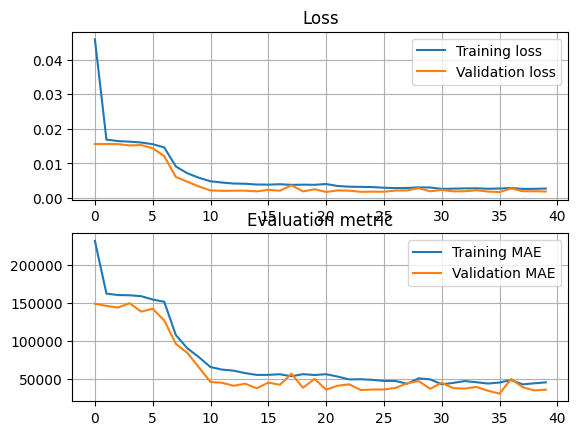

In [74]:
plt.subplot(2, 1, 1)
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.title("Loss")
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(mae_train, label='Training MAE')
plt.plot(mae_valid, label='Validation MAE')
plt.title("Evaluation metric")
plt.grid()
plt.legend()

#### 1.1.4. RNN for multivariate time series prediction

Thanks to the flexibility of neural networks, we can easily adapt our RNN to  use multiple variables to forecast the next rail ridership value. We can use both the rail and bus historical values, and also decide to use the day type as well.

Since we can know what type of day tomorrow will be, we can actually use tomorrow's day type and past rail and bus ridership values to predict tomorrow's rail ridership value.

Let's create a dataset with the bus and rail ridership values, as well as the day type shifted by one day and converted to numerical values with one-hot encoding.

In [112]:
df_mulvar = df_ridership[["rail", "bus"]] / 1e6 # use both rail & bus series as input
df_mulvar["next_day_type"] = df_ridership["day_type"].shift(-1) # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype=float) # one-hot encode day type

Split in train, validation and test sets.

In [157]:
mulvar_train = torch.FloatTensor(df_mulvar["2016-01":"2018-12"].values)
mulvar_valid = torch.FloatTensor(df_mulvar["2019-01":"2019-05"].values)
mulvar_test = torch.FloatTensor(df_mulvar["2019-06":].values)

We only want to predict the rail ridership for the moment. To specify this, we can tweak the `TimeSeriesDataset` class to specify that only keep the first value in the target. Another way to do it is to create a new `MulvarTimeSeriesDataset` class, inheriting from the `TimeSeriesDataset` class, and tweak the `__getitem__` method.

In [208]:
class MulvarTimeSeriesDataset(TimeSeriesDataset):
  def __getitem__(self, idx):
    window, target = super().__getitem__(idx)
    return window, target[:1]

Then, we can proceed as we did previously.

In [209]:
window_length = 56
mulvar_train_set = MulvarTimeSeriesDataset(mulvar_train, window_length)
mulvar_train_loader = DataLoader(mulvar_train_set, batch_size=32, shuffle=True)
mulvar_valid_set = MulvarTimeSeriesDataset(mulvar_valid, window_length)
mulvar_valid_loader = DataLoader(mulvar_valid_set, batch_size=32, shuffle=True)
mulvar_test_set = MulvarTimeSeriesDataset(mulvar_test, window_length)
mulvar_test_loader = DataLoader(mulvar_test_set, batch_size=32, shuffle=True)

In [210]:
torch.manual_seed(10)
multivar_model = MLRnnModel(input_size=5, hidden_size=20, num_layers=1, output_size=1).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.Adam(multivar_model.parameters(), lr=0.001)
metric = torchmetrics.MeanAbsoluteError().to(device)
n_epochs = 40
train_losses, valid_losses, mae_train, mae_valid = train(multivar_model, optimizer, loss_fn, metric, mulvar_train_loader, mulvar_valid_loader, n_epochs)

Epoch 1/40, Training Loss: 0.1925, Valid Loss: 0.0272
Epoch 1/40, Training Eval Metric: 0.5613, Valid Eval Metric: 0.2229
Epoch 2/40, Training Loss: 0.0169, Valid Loss: 0.0112
Epoch 2/40, Training Eval Metric: 0.1465, Valid Eval Metric: 0.1227
Epoch 3/40, Training Loss: 0.0094, Valid Loss: 0.0072
Epoch 3/40, Training Eval Metric: 0.1237, Valid Eval Metric: 0.0876
Epoch 4/40, Training Loss: 0.0058, Valid Loss: 0.0040
Epoch 4/40, Training Eval Metric: 0.0906, Valid Eval Metric: 0.0624
Epoch 5/40, Training Loss: 0.0038, Valid Loss: 0.0024
Epoch 5/40, Training Eval Metric: 0.0663, Valid Eval Metric: 0.0450
Epoch 6/40, Training Loss: 0.0028, Valid Loss: 0.0016
Epoch 6/40, Training Eval Metric: 0.0526, Valid Eval Metric: 0.0371
Epoch 7/40, Training Loss: 0.0023, Valid Loss: 0.0013
Epoch 7/40, Training Eval Metric: 0.0458, Valid Eval Metric: 0.0341
Epoch 8/40, Training Loss: 0.0021, Valid Loss: 0.0012
Epoch 8/40, Training Eval Metric: 0.0424, Valid Eval Metric: 0.0337
Epoch 9/40, Training Los

In [211]:
mae_train = [x * 1e6 for x in mae_train]
mae_valid = [x * 1e6 for x in mae_valid]

In [212]:
mae_valid[-1]

31640.16827940941

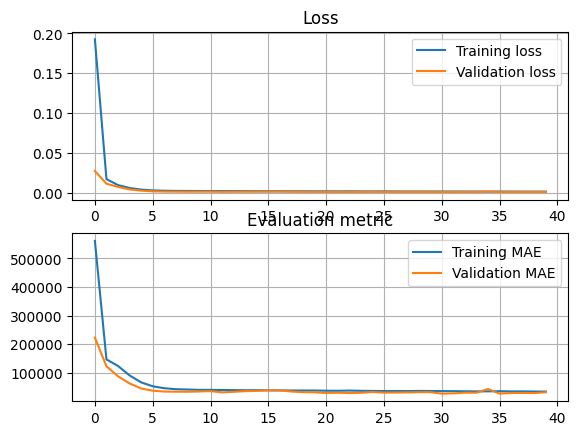

In [213]:
plt.subplot(2, 1, 1)
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.title("Loss")
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(mae_train, label='Training MAE')
plt.plot(mae_valid, label='Validation MAE')
plt.title("Evaluation metric")
plt.grid()
plt.legend()

We can also predict both the values of rail and bus riderships at the same time. To do so, we only need to change:


*   The number of values taken in consideration in the target in the `MulvarTimeSeriesDataset` class.
*   The number of output neurons in the model.

You also need to evaluate the model seperately for train and bus ridership.


#### 1.1.5. Forecast several time steps ahead

We can use the models we trained to forecast the ridership values for the next day, but what if we want to predict several days ahead?

A simple way to do this is to predict the next day, concatenate the prediction to the past values, move the window to predict the next day, and repeat the process for a desired number of steps.

The follow code does just so for 14 steps ahead.

In [222]:
n_steps = 14
univar_model.eval()
with torch.no_grad():
    X = rail_valid[:window_length].unsqueeze(dim=0).to(device)
    for step_ahead in range(n_steps):
        y_pred_one = univar_model(X)
        X = torch.cat([X, y_pred_one.unsqueeze(dim=0)], dim=1)
    Y_pred = X[0, -n_steps:, 0]

Run the next cell to display the result.

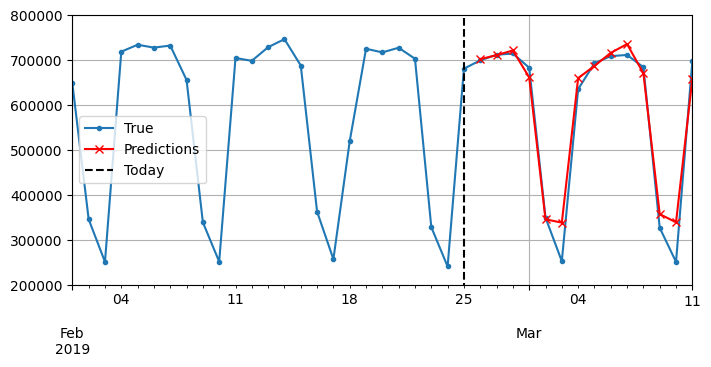

In [226]:
# The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
# on 2019-03-11. That's 14 days in total.
Y_pred = pd.Series(X[0, -14:, 0].cpu().numpy(), index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
# Convert the rail_valid tensor to a pandas Series with a date range index
rail_valid_series = pd.Series(rail_valid.cpu().numpy().flatten(), index=pd.date_range("2019-01-01", periods=len(rail_valid)))
# Now you can slice using date strings
(rail_valid_series["2019-02-01":"2019-03-11"] * 1e6).plot(label="True", marker=".", ax=ax) # Multiply by 1e6 here
(Y_pred * 1e6).plot(label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
plt.show()

It does not look too bad! However, note that if the model makes an error at one time step, it will impact the next forecasts. Errors tend to accumulate and therefore this approach is preferable if you want to only predict a small number of steps ahead.
Another option is to train to your RNN to predict the next steps (here 14) at once. We will not cover that here, but you can look at Chapter 15 notebook for the "Hands on ML" book for the implmentation of this approach.

#### 1.1.6. Using LSTM and GRU

To use LSTM or GRU, you can use the dedicated `nn.LSTM` or `nn.GRU` modules. LSTM and GRU work better for longer sequences, as the vanilla RNN suffers from vaniashing gradient when sequences are longer.

In [227]:
class SimpleLSTMModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True) # batch_first=True because the shape of our data is [batch size, window length, dimensionality]
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])

In [246]:
torch.manual_seed(10)
univar_lstm_model = SimpleLSTMModel(input_size=1, hidden_size=20, output_size=1).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.Adam(univar_lstm_model.parameters(), lr=0.005)
metric = torchmetrics.MeanAbsoluteError().to(device)
n_epochs = 40
train_losses, valid_losses, mae_train, mae_valid = train(univar_lstm_model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs)

Epoch 1/40, Training Loss: 0.0291, Valid Loss: 0.0169
Epoch 1/40, Training Eval Metric: 0.2011, Valid Eval Metric: 0.1374
Epoch 2/40, Training Loss: 0.0164, Valid Loss: 0.0165
Epoch 2/40, Training Eval Metric: 0.1598, Valid Eval Metric: 0.1383
Epoch 3/40, Training Loss: 0.0161, Valid Loss: 0.0158
Epoch 3/40, Training Eval Metric: 0.1597, Valid Eval Metric: 0.1444
Epoch 4/40, Training Loss: 0.0159, Valid Loss: 0.0155
Epoch 4/40, Training Eval Metric: 0.1576, Valid Eval Metric: 0.1408
Epoch 5/40, Training Loss: 0.0153, Valid Loss: 0.0139
Epoch 5/40, Training Eval Metric: 0.1550, Valid Eval Metric: 0.1438
Epoch 6/40, Training Loss: 0.0137, Valid Loss: 0.0121
Epoch 6/40, Training Eval Metric: 0.1457, Valid Eval Metric: 0.1162
Epoch 7/40, Training Loss: 0.0112, Valid Loss: 0.0099
Epoch 7/40, Training Eval Metric: 0.1285, Valid Eval Metric: 0.1159
Epoch 8/40, Training Loss: 0.0097, Valid Loss: 0.0070
Epoch 8/40, Training Eval Metric: 0.1191, Valid Eval Metric: 0.0944
Epoch 9/40, Training Los

In [247]:
mae_train = [x * 1e6 for x in mae_train]
mae_valid = [x * 1e6 for x in mae_valid]

In [248]:
mae_valid[-1]

34813.7766122818

In [235]:
class SimpleGRUModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.GRU(input_size, hidden_size, batch_first=True) # batch_first=True because the shape of our data is [batch size, window length, dimensionality]
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])

In [243]:
torch.manual_seed(10)
univar_GRU_model = SimpleGRUModel(input_size=1, hidden_size=20, output_size=1).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.Adam(univar_GRU_model.parameters(), lr=0.005)
metric = torchmetrics.MeanAbsoluteError().to(device)
n_epochs = 40
train_losses, valid_losses, mae_train, mae_valid = train(univar_GRU_model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs)

Epoch 1/40, Training Loss: 0.0455, Valid Loss: 0.0159
Epoch 1/40, Training Eval Metric: 0.2399, Valid Eval Metric: 0.1521
Epoch 2/40, Training Loss: 0.0155, Valid Loss: 0.0151
Epoch 2/40, Training Eval Metric: 0.1546, Valid Eval Metric: 0.1505
Epoch 3/40, Training Loss: 0.0150, Valid Loss: 0.0143
Epoch 3/40, Training Eval Metric: 0.1552, Valid Eval Metric: 0.1452
Epoch 4/40, Training Loss: 0.0142, Valid Loss: 0.0141
Epoch 4/40, Training Eval Metric: 0.1487, Valid Eval Metric: 0.1279
Epoch 5/40, Training Loss: 0.0134, Valid Loss: 0.0123
Epoch 5/40, Training Eval Metric: 0.1445, Valid Eval Metric: 0.1331
Epoch 6/40, Training Loss: 0.0126, Valid Loss: 0.0109
Epoch 6/40, Training Eval Metric: 0.1352, Valid Eval Metric: 0.1143
Epoch 7/40, Training Loss: 0.0102, Valid Loss: 0.0076
Epoch 7/40, Training Eval Metric: 0.1154, Valid Eval Metric: 0.1064
Epoch 8/40, Training Loss: 0.0083, Valid Loss: 0.0079
Epoch 8/40, Training Eval Metric: 0.1029, Valid Eval Metric: 0.1112
Epoch 9/40, Training Los

In [244]:
mae_train = [x * 1e6 for x in mae_train]
mae_valid = [x * 1e6 for x in mae_valid]

In [245]:
mae_valid[-1]

33475.62626004219

### 2.2. Character-level RNN: RNN for NLP (Extra resources tutorials)

If you wish to see how to RNNs can be used to analyse or generate text character per character, feel free to have a look at these extra material tutorials.



*   [NLP From Scratch: Classifying Names with a Character-Level RNN](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html)
*   [NLP From Scratch: Generating Names with a Character-Level RNN](https://pytorch.org/tutorials/intermediate/char_rnn_generation_tutorial.html)
*   [Shakespeare poetry generation with recurrent neural networks (RNNs)](https://colab.research.google.com/github/ccc-frankfurt/Practical_ML_SS21/blob/main/week06/Shakespeare_Poetry_Generation_RNN_LSTM_solution.ipynb)




## Coding Time 2: Using Transformer-based models with the Hugging Face Transformers library

In this part, we will see how to use transformers from the Huggingface Transformers libray. You will load and use pre-trained Transformer models to play with them directly.

If you want to see how to implement a Transformer from scratch, you can have a look at the following extra resources tutorials:


*   Chapter 15 of the "Hands on ML" book, code available in the [Chapter 15 notebook](https://github.com/ageron/handson-mlp/blob/main/15_transformers_for_nlp_and_chatbots.ipynb).
*   [DataCamp tutorial on "Building a Transformer with PyTorch"](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch).




In [251]:
if "google.colab" in sys.modules:
    %pip install -q -U transformers # HuggingFace Transformers library
    %pip install -q -U datasets # HuggingFace Datasets library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.


Hugging Face is an AI company which is providing one of the biggest repository of models available in open-source. They maintain the Transformers library, which allow you to load and use a large variety of pretrained models for natural language processing (NLP), computer vision, and audio and speech processing tasks.

The Transformers library give you access to a lot of models based on the Transformer architecture, but also to non-Transformer models like Convolutional Neural Networks (CNNs) for computer vision tasks (we will talk about CNNs next week).
On top of this, the library support multiple frameworks, including TensorFlow and PyTorch.

In [252]:
from transformers import pipeline

Let's have a look at using some model for NLP tasks such as sentiment analysis and translation. The simplest way to use this library is to use the `transformers.pipeline()` function. You just need to specify the type of task you want to perform, and eventually a specific pre-trained model you want to use (else it will use a default one), and it downloads the model which you can use directly, or fine-tune on your own data (you will see this in the transfer learning lectures). You can read more about it at the Hugging Face documentation.

In [253]:
classifier = pipeline("sentiment-analysis")  # many other tasks are available

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


We can now use the loaded model to perform predictions on input text sequences.

In [254]:
classifier("I love COMPSCI 714.")

[{'label': 'POSITIVE', 'score': 0.9996547698974609}]

In [255]:
classifier("I am tired today.")

[{'label': 'NEGATIVE', 'score': 0.9997768998146057}]

**Important note**: Sentiment analysis predictions can be very biased, and output questionnable results. Try to play with it to see if you can generate some questionnable predictions.
Such biases can come for example from the training data itself (e.g., some topics getting more negative mentions than others), or the labelling (there are plenty of cases where it is hard to objectively say if a sentence if carrying a "positive" or "negative" sentiment).

Let's now try a translation task with the google-t5/t5-small language model.

In [257]:
translator = pipeline(task="translation_en_to_fr", model="google-t5/t5-small")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cuda:0


In [272]:
text = "I went on holiday on the South Island"
translator(text)

[{'translation_text': "Je suis allé en vacances sur l'île du Sud"}]

This model's version is good for simple translation, but it shows some limitations for slightly more complicated ones.

Here are some links to some more examples of the `pipeline()` function being [used for different tasks](https://huggingface.co/docs/transformers/en/task_summary), a [list of available models](https://huggingface.co/models) and the [list of available tasks](https://huggingface.co/tasks). Note that some models might require specific access rights, and also specific tools to be installed, but there is already a bunch of things you can do without worrying about that.

**To continue**: Have fun trying different things with the Hugging Face Transformers library, and have a look at the Transformer architecture code!
